In [4]:
import os
print(os.getcwd())

c:\Users\lilit\bluestock_mf_capstone\notebooks


In [5]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

print(nav.head())
print(nav.shape)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
(46000, 3)


In [6]:
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
transactions = pd.read_csv("../data/processed/transactions_clean.csv")
folios = pd.read_csv("../data/processed/06_industry_folio_count.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

for name, df in {
    "aum": aum,
    "sip": sip,
    "category": category,
    "transactions": transactions,
    "folios": folios,
    "holdings": holdings
}.items():
    print("\n" + "="*50)
    print(name.upper())
    print(df.columns.tolist())


AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

CATEGORY
['month', 'category', 'net_inflow_crore']

TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

FOLIOS
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


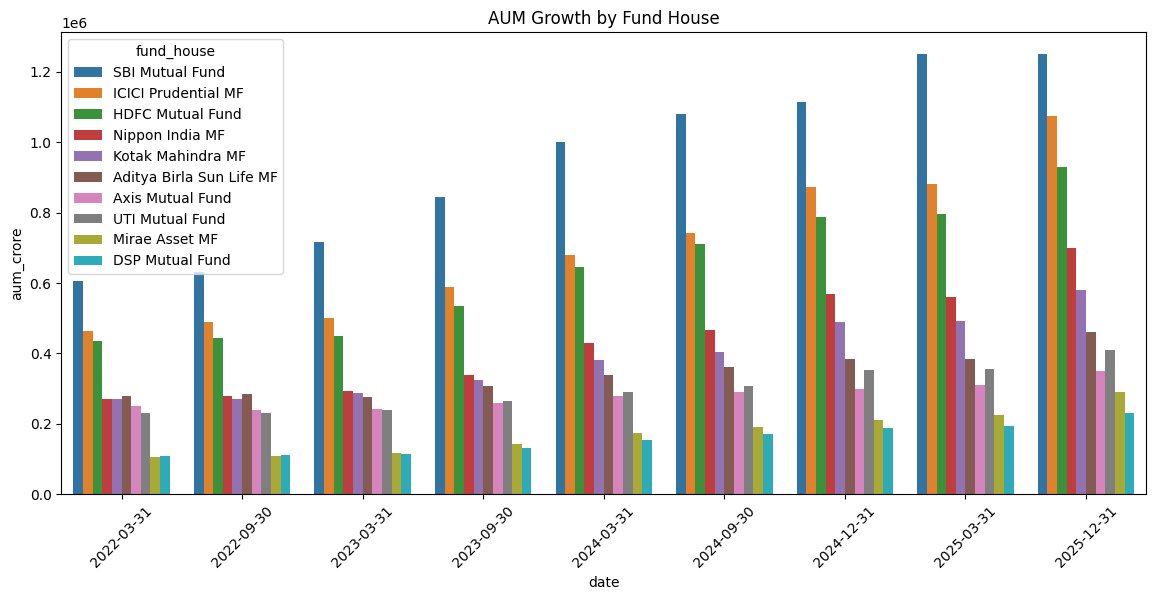

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_crore",
    hue="fund_house"
)

plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House")
plt.show()

In [8]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.show()

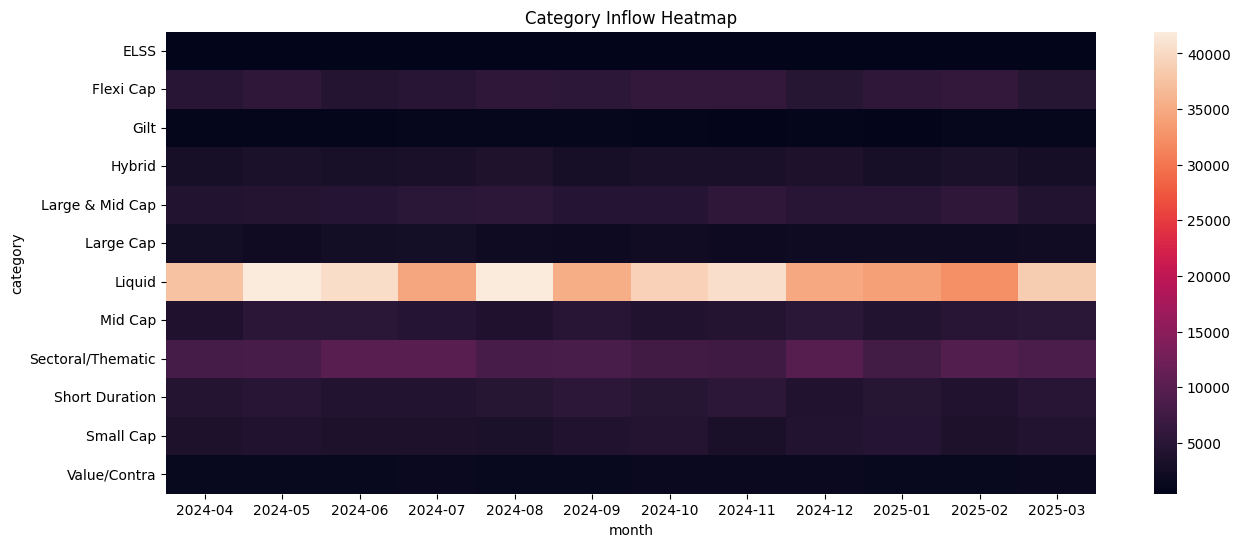

In [9]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(pivot)

plt.title("Category Inflow Heatmap")

plt.show()

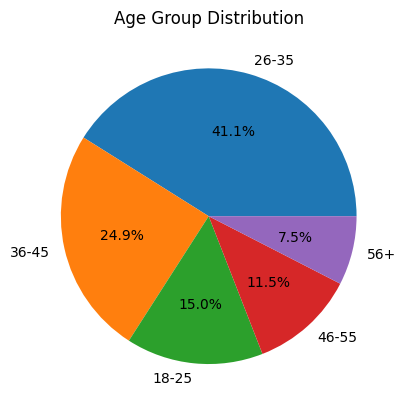

In [10]:
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.show()

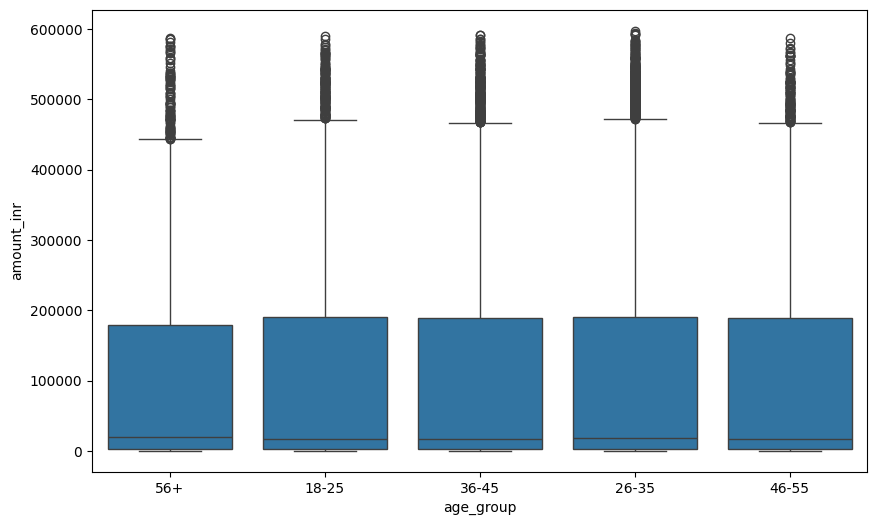

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.show()

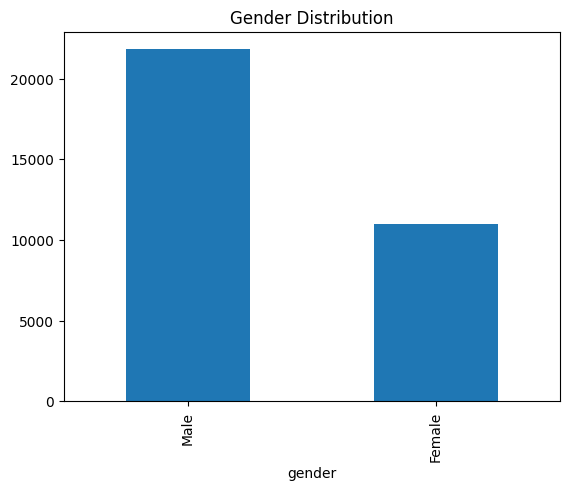

In [12]:
transactions["gender"].value_counts().plot.bar()

plt.title("Gender Distribution")

plt.show()

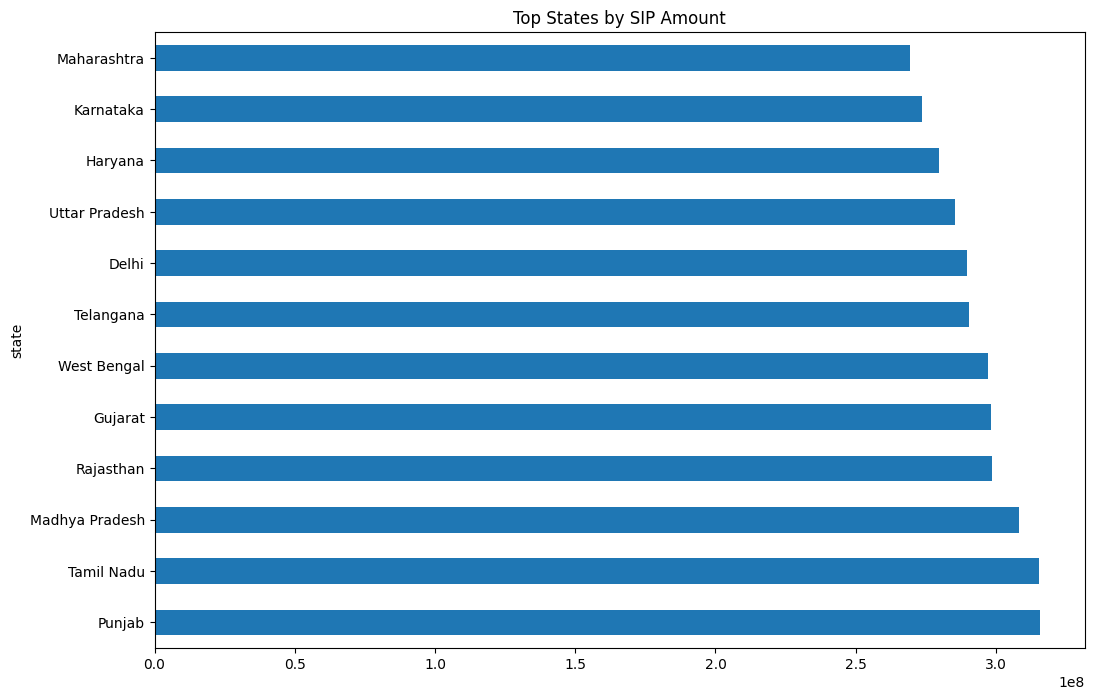

In [13]:
state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_sip.head(15).plot.barh()

plt.title("Top States by SIP Amount")

plt.show()

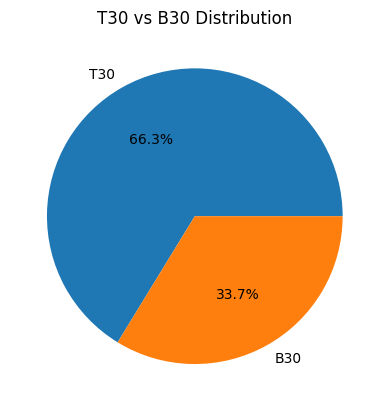

In [14]:
transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.show()

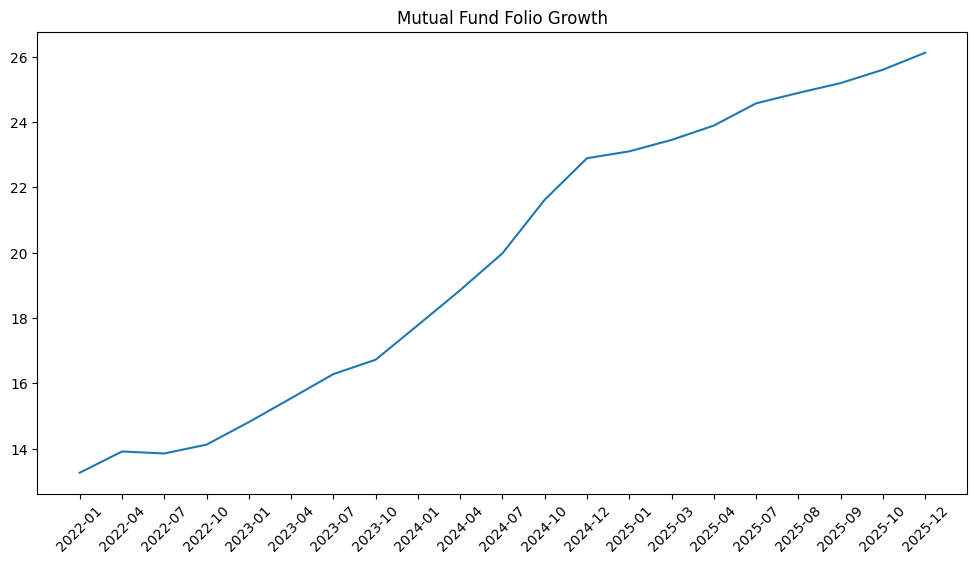

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.xticks(rotation=45)

plt.title("Mutual Fund Folio Growth")

plt.show()

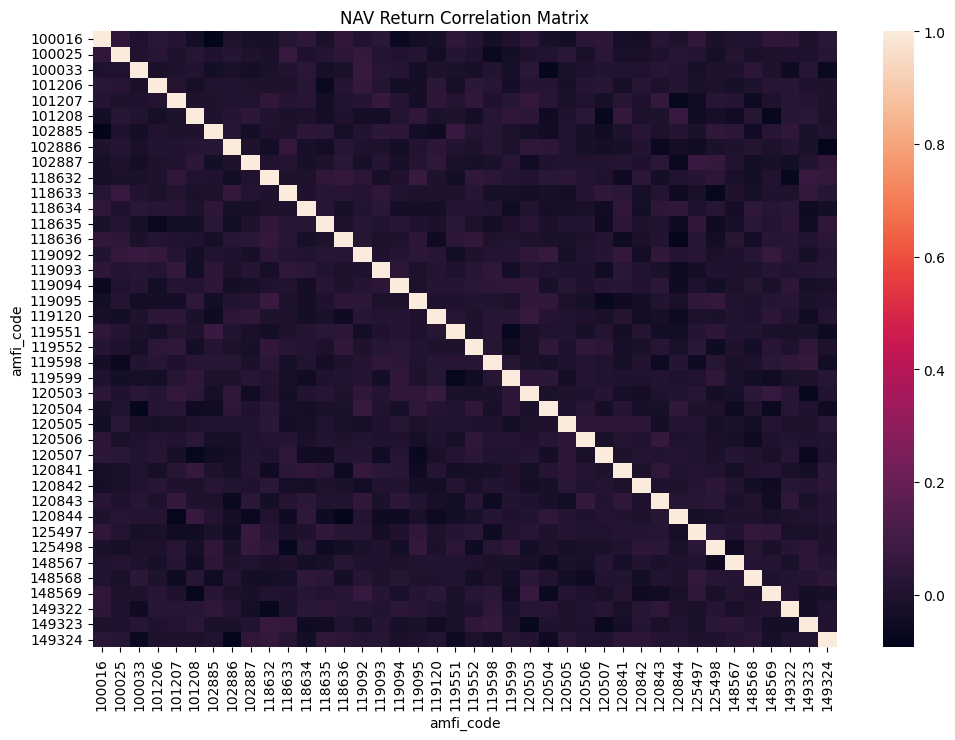

In [16]:
nav["date"] = pd.to_datetime(nav["date"])

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr)

plt.title("NAV Return Correlation Matrix")

plt.show()

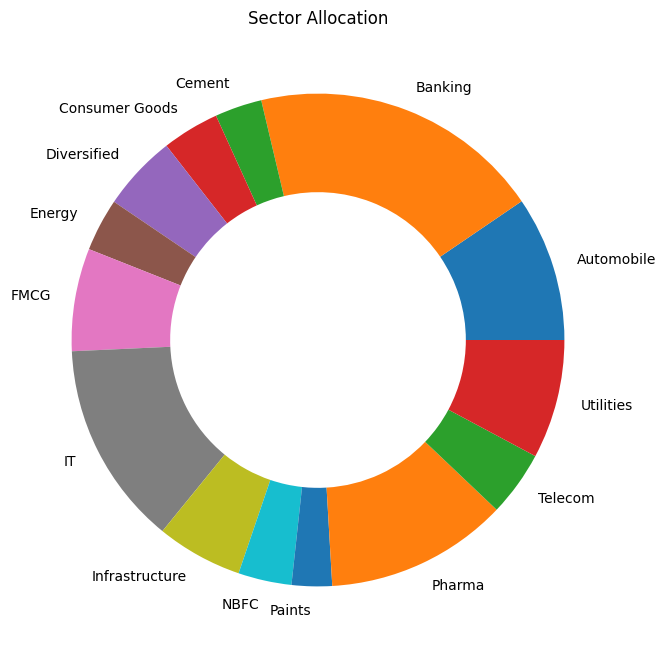

In [17]:
sector = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation")

plt.show()

# Key EDA Findings

1. Mutual fund NAVs generally exhibited an upward trend from 2022–2025.
2. Several schemes experienced temporary corrections during volatile market periods.
3. SBI Mutual Fund maintained one of the highest AUM levels among fund houses.
4. SIP inflows increased steadily throughout the observation period.
5. Equity-oriented categories attracted the highest net inflows.
6. Investors in the 25–35 age group contributed the highest investment amounts.
7. Male investors accounted for a larger share of transactions.
8. T30 cities generated more SIP activity than B30 cities.
9. Most mutual fund schemes displayed positive NAV return correlations.
10. Financial and Technology sectors contributed significant portfolio weights.